In [1]:
# Import packages
import PKA_Sleep as PKA
from PKA_Sleep import Graphing_Utils as graph
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
graph.make_bigandbold()
from scipy import stats
from matplotlib import cm
import statsmodels.formula.api as smf

In [2]:
experiment_names = ['ltFLiPAKARmemEEGEMG0009',
                    'ltFLiPAKARmemEEGEMG0010',
                    'dgFLiPmemAKAREEGEMG0003',
                    'dgFLiPmemAKAREEGEMG0008',
                    'ltFLiPAKARmemEEGEMG0036',
                    'ltFLiPAKARmemEEGEMG0043',
                    'kgFLiPAKAREEGEMG0009',
                    'ltFLiPAKARmemEEGEMG0055',
                    'ltFLiPAKARmemEEGEMG0068',
                    'ltFLiPAKARmemEEGEMG0072',
                    'ltFLiPAKARmemEEGEMG0085',
                    'ltFLiPAKARmemEEGEMG0090-1',
                    'ltFLiPAKARmemEEGEMG0094',
                    'ltFLiPAKARmemEEGEMG0097-1',
                    'ltFLiPAKARmemEEGEMG0098-1',
                    'ltFLiPAKARmemEEGEMG0099-1',
                    'ltFLiPAKARmemEEGEMG0099-2',
                    'ltFLiPAKARmemEEGEMG0100-1',
                    'ltFLiPAKARmemEEGEMG0101-1',
                    'ltFLiPAKARmemEEGEMG0102-1',
                    'ltFLiPAKARmemEEGEMG0103-1']
mouse_names = ['3825',
                '3825',
                '3825',
                '3825',
                '4346-t5-7',
                '4346-t5-7',
                '4507',
                '4502',
                '4507',
                '4610',
                '4713',
                '4769',
                '4775',
                '5782',
                '5007',
                '5075',
                '5075',
                '5078',
                '5046',
                '5047',
                '5076']

In [13]:
##------------------------------------ Baseline Data ---------------------------##
parent_data_directory = '/Volumes/yaochen/Active/Lizzie/FLP_data/'

df = pd.read_excel('/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/FLiP_Experiment_Summary.xlsx')
raw_datadirs = [os.path.join(parent_data_directory, e) for e in experiment_names]
baseline_idxs = [(int(d['Baseline Start'].values),int(d['Baseline End'].values)) 
                  for d in [df.loc[df['Experiment Name'] == e] for e in experiment_names]]
excluded_acqs = PKA.choose_excluded_acqs(raw_datadirs, first_acqs = 3, specific_acqs = False, pull_baseline = True, 
                                          baseline_idxs = baseline_idxs)

# Set FLiP class parameters and build classes
epoch_len = 4
filter_bounds = [None, None]
binned = False
shuffle_window = 40
experimental_sensor = 'FLIM-mAKAR'
sleep_states = True
microarousals = True
seperate_acqs = False
shuffled = True

FLP_classes_dict = PKA.build_classes(experiment_names, mouse_names, epoch_len = epoch_len, 
                                     filter_bounds = filter_bounds, binned = binned, 
                                     shuffle_window = shuffle_window, experimental_sensor = experimental_sensor, 
                                     sleep_states = sleep_states, microarousals = microarousals, 
                                     seperate_acqs = seperate_acqs, emp_lifetime = False,
                                     parent_data_directory = parent_data_directory, gather_timestamps = True, 
                                     exclude_acqs = excluded_acqs)
MA_to_NREM = True
NREM_wake_only = False
if NREM_wake_only:
    NREM_status = '_NREMonly'
else:
    NREM_status = ''
if MA_to_NREM:
    MA_status = '_noMA'
else:
    MA_status = ''
data_keys = ['Distance', experimental_sensor, 'Timepoints']
if shuffled:
    data_keys.append('Shuffled')
grouped_experiments = {a:{'Experiment Classes':[FLP_classes_dict['Experiment Classes'][i] 
                                                for i in range(len(FLP_classes_dict['Experiment Classes'])) 
                                                               if str(FLP_classes_dict['Animal Names'][i]) == a],
                         'Experiment Names':[FLP_classes_dict['Experiment Names'][i] 
                                                for i in range(len(FLP_classes_dict['Experiment Names'])) 
                                                               if str(FLP_classes_dict['Animal Names'][i]) == a],
                         'Wake Distance Data': {k: [] for k in data_keys},
                          'Sleep Duration Data': {k: [] for k in data_keys},
                         'ZT Time': []}
                            for a in np.unique(FLP_classes_dict['Animal Names'])}
bins = np.arange(0, 25, 2)
zt_cat_key = {i: 'ZT'+str(bins[i-1]) + '-ZT' + str(bins[i]) for i in np.arange(1,len(bins))}
for a in grouped_experiments.keys():
    for b, FLP_exp in zip(grouped_experiments[a]['Experiment Names'], grouped_experiments[a]['Experiment Classes']):
        time_range = [FLP_exp.Time[0], FLP_exp.Time[-1]]
        data_dict = PKA.LFT_WakeSleepDistance(FLP_exp, time_range, MA_to_NREM = MA_to_NREM, NREM_wake_only = NREM_wake_only, 
                                        shuffled = shuffled,buffer = 0, get_wake_distance = True, get_sleep_distance = False)
        for key, value in data_dict.items():
            grouped_experiments[a]['Wake Distance Data'][key].append(value[~np.isnan(data_dict['Distance'])])
        
        data_dict = PKA.LFT_WakeSleepDistance(FLP_exp, time_range, MA_to_NREM = MA_to_NREM, NREM_wake_only = NREM_wake_only, 
                                        shuffled = shuffled,buffer = 0, get_wake_distance = False, get_sleep_distance = True)
        for key, value in data_dict.items():
            grouped_experiments[a]['Sleep Duration Data'][key].append(value[~np.isnan(data_dict['Distance'])])
        if len(grouped_experiments[a]['Wake Distance Data'][key][-1]) != len(grouped_experiments[a]['Sleep Duration Data'][key][-1]):
            real_val = min([len(grouped_experiments[a]['Wake Distance Data'][key][-1]),
                            len(grouped_experiments[a]['Sleep Duration Data'][key][-1])])
            for key in data_dict.keys():
                grouped_experiments[a]['Wake Distance Data'][key][-1] = grouped_experiments[a]['Wake Distance Data'][key][-1][:real_val]
                grouped_experiments[a]['Sleep Duration Data'][key][-1] = grouped_experiments[a]['Sleep Duration Data'][key][-1][:real_val]
            
        zt = [FLP_exp.ZeitTime[FLP_exp.Time == t][0] for t in grouped_experiments[a]['Sleep Duration Data'][key][-1]]
        cat_zt_idx = np.digitize(zt, bins = bins)
        cat_zt = np.array([None]*(len(cat_zt_idx)))
        for i in zt_cat_key.keys():
            cat_zt[cat_zt_idx == i] = zt_cat_key[i]
        grouped_experiments[a]['ZT Time'].append(cat_zt)
    grouped_experiments[a]['Grouped Data'] = {
        experimental_sensor: np.concatenate([stats.zscore(w) for w in grouped_experiments[a]['Wake Distance Data'][experimental_sensor]]),
        'Wake Distance': np.concatenate(grouped_experiments[a]['Wake Distance Data']['Distance']),
        'Sleep Duration': np.concatenate([stats.zscore(w) for w in grouped_experiments[a]['Sleep Duration Data']['Distance']]),
        'ZT Time': np.concatenate(grouped_experiments[a]['ZT Time'])
    }
    if shuffled:
        grouped_experiments[a]['Grouped Data']['Shuffled'] = np.concatenate(
            [stats.zscore(w) for w in grouped_experiments[a]['Wake Distance Data']['Shuffled']])
num_LFT_bins = 9
waking_binsize = 16

/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_3763/3523890299.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  baseline_idxs = [(int(d['Baseline Start'].values),int(d['Baseline End'].values))


You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this expe

/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_3763/1823273323.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap_name)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


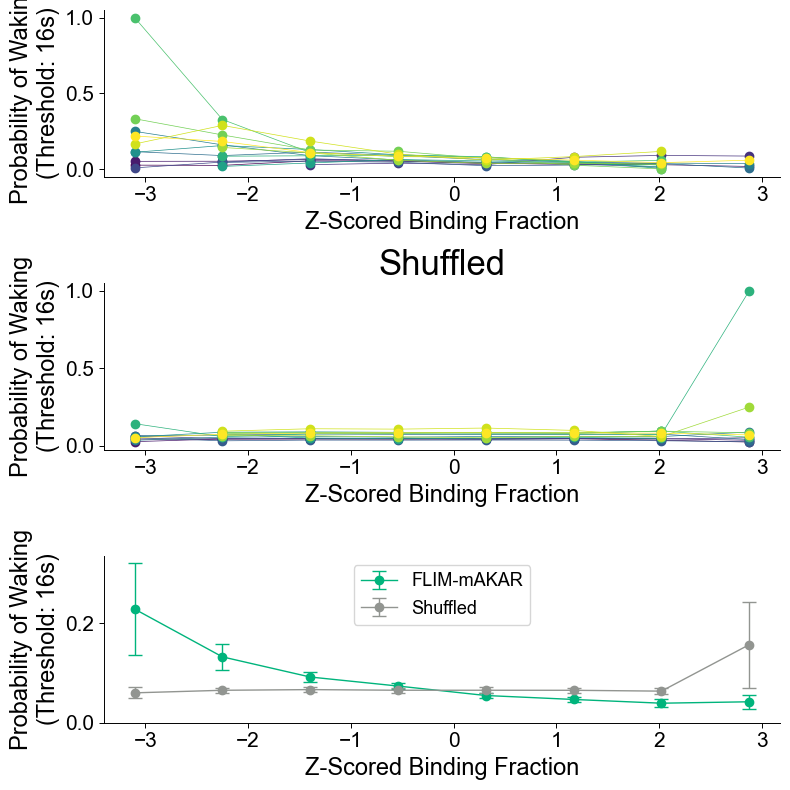

In [14]:
fig_savedir = '/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Working_figs/PKA_Sleep_Project/Wake_probability/'
num_animals = len(np.unique(FLP_classes_dict['Animal Names']))
cmap_name = 'viridis'
colormap = cm.get_cmap(cmap_name)
colors_list = colormap(np.linspace(0, 1, num_animals))
region = 'mPFC'

all_wakeprops_EXP = np.zeros([num_animals, num_LFT_bins-1])
all_wakeprops_EXP[:] = np.nan
all_wakeprops_SHUFF = np.zeros([num_animals, num_LFT_bins-1])
all_wakeprops_SHUFF[:] = np.nan

all_vals = np.concatenate([grouped_experiments[a]['Grouped Data'][experimental_sensor] for a in grouped_experiments.keys()])
bin_edges =  np.linspace(min(all_vals), max(all_vals),9)

fig, axes = plt.subplots(figsize = [8, 8], nrows = 3)
for i,a in enumerate(grouped_experiments.keys()):
    fig, axes[0], wake_prop_EXP, bin_centers = PKA.plot_wake_probability(fig, axes[0], 
                                                                     grouped_experiments[a]['Grouped Data'][experimental_sensor], 
                                                            grouped_experiments[a]['Grouped Data']['Wake Distance'], bin_edges,
                                                           waking_binsize = waking_binsize, include_n = False, savedir = False, 
                                                            color = colors_list[i], confidence_int = False)
    fig, axes[1], wake_prop_SHUFF, bin_centers = PKA.plot_wake_probability(fig, axes[1], 
                                                                            grouped_experiments[a]['Grouped Data']['Shuffled'], 
                                                            grouped_experiments[a]['Grouped Data']['Wake Distance'], bin_edges,
                                                           waking_binsize = waking_binsize, include_n = False, savedir = False, 
                                                            color = colors_list[i], confidence_int = False)

    all_wakeprops_EXP[i] = wake_prop_EXP[:,0]/wake_prop_EXP[:,1]
    all_wakeprops_SHUFF[i] = wake_prop_SHUFF[:,0]/wake_prop_SHUFF[:,1]

axes[2].errorbar(bin_centers, np.nanmean(all_wakeprops_EXP, axis = 0), yerr = stats.sem(all_wakeprops_EXP, axis = 0, nan_policy = 'omit'),  
            fmt = 'o', color = '#00b47c', capsize = 5, linewidth = 1, linestyle = '-', label = 'FLIM-mAKAR')

axes[2].errorbar(bin_centers, np.nanmean(all_wakeprops_SHUFF, axis = 0), yerr = stats.sem(all_wakeprops_SHUFF, axis = 0, nan_policy = 'omit'),  
            fmt = 'o', color = '#929591', capsize = 5, linewidth = 1, linestyle = '-', label = 'Shuffled')

axes[2].legend(fontsize = 13)
graph.thick_axes(fig, axes, width = 0.7)
axes[2].set_ylim([0,axes[2].get_ylim()[1]])

graph.label_axes(axes[1], y = 'Probability of Waking\n(Threshold: ' + str(waking_binsize) + 's)', x = 'Z-Scored Binding Fraction', 
                 title = 'Experimental')
graph.label_axes(axes[1], y = 'Probability of Waking\n(Threshold: ' + str(waking_binsize) + 's)', x = 'Z-Scored Binding Fraction', 
                 title = 'Shuffled')
graph.label_axes(axes[2], y = 'Probability of Waking\n(Threshold: ' + str(waking_binsize) + 's)', x = 'Z-Scored Binding Fraction')

fig.tight_layout()
fig.savefig(os.path.join(fig_savedir, 'WakingProb_'+region+'_baseline'+NREM_status+MA_status+'_binsize'+str(waking_binsize)+'.png'))
fig.savefig(os.path.join(fig_savedir, 'WakingProb_'+region+'_baseline'+NREM_status+MA_status+'_binsize'+str(waking_binsize)+'.ps'))


Observed difference in decay rates: 0.4710
P-value (permutation test): 2.64e-02


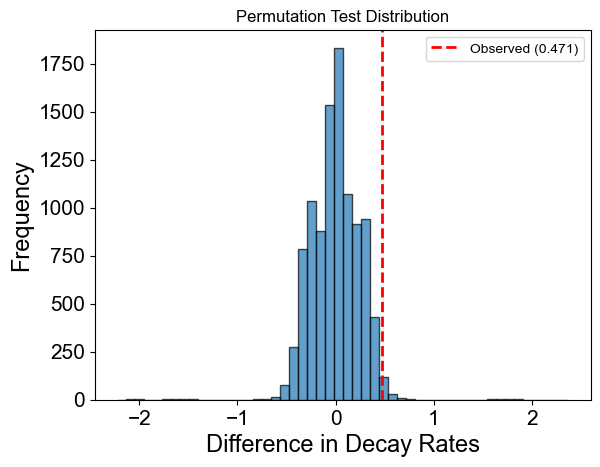

EXPERIMENTAL:
Position β: -0.224783
P-value: 3.552253e-13
Z statstic: -7.271611e+00

SHUFFLED:
Position β: 0.017442
P-value: 2.473720e-01
Z statstic: 1.156756e+00


In [15]:
##------------------------------------ Stats ---------------------------##
position = list(range(1,num_LFT_bins))*len(grouped_experiments.keys())
subject_id = np.concatenate([[e]*8 for e in grouped_experiments.keys()])
measurements_exp = np.concatenate(all_wakeprops_EXP)
measurements_shuff = np.concatenate(all_wakeprops_SHUFF)
data = pd.DataFrame({
            'position': list(position) * 2,
            'subject_id': list(subject_id) * 2,
            'measurement': list(measurements_exp) + list(measurements_shuff),  # your measurements
            'log_measurement': list(np.log(measurements_exp)) + list(np.log(measurements_shuff)),
            'condition': ['experimental']*len(measurements_exp) + ['shuffled']*len(measurements_shuff)  # or however you've organized it
            })


data_clean = data.dropna(subset=['log_measurement', 'position', 'condition', 'subject_id'])

#Test to confirm due to shuffled data
p_perm = PKA.WakeProb_PermutationTest(data)

#Test with mixed linear model 
#Experimental only
df_exp = data_clean[data_clean['condition'] == 'experimental']
model_exp = smf.mixedlm('log_measurement ~ position', 
                        data=df_exp, 
                        groups=df_exp['subject_id']).fit()

print("EXPERIMENTAL:")
print(f"Position β: {model_exp.params['position']:.6f}")
print(f"P-value: {model_exp.pvalues['position']:.6e}")
print(f"Z statstic: {model_exp.tvalues['position']:.6e}")

# Shuffled only
df_shuf = data_clean[data_clean['condition'] == 'shuffled']
model_shuf = smf.mixedlm('log_measurement ~ position', 
                         data=df_shuf, 
                         groups=df_shuf['subject_id']).fit()

print("\nSHUFFLED:")
print(f"Position β: {model_shuf.params['position']:.6f}")
print(f"P-value: {model_shuf.pvalues['position']:.6e}")
print(f"Z statstic: {model_shuf.tvalues['position']:.6e}")


In [16]:
#- - - - - - - - - - - Logistical Regression - - - - - - - - - - - - - - - - - - -
wake_distance_vals = np.concatenate([grouped_experiments[a]['Grouped Data']['Wake Distance'] for a in grouped_experiments.keys()])
sleep_duration_vals = np.concatenate([grouped_experiments[a]['Grouped Data']['Sleep Duration'] for a in grouped_experiments.keys()])
pka_sp = np.concatenate([grouped_experiments[a]['Grouped Data']['FLIM-mAKAR'] for a in grouped_experiments.keys()])
pka_sp_shuff = np.concatenate([grouped_experiments[a]['Grouped Data']['Shuffled'] for a in grouped_experiments.keys()])
animal_list = np.concatenate([[a for i in range(len(grouped_experiments[a]['Grouped Data']['FLIM-mAKAR']))] 
                            for a in grouped_experiments.keys()])
cat_zt = np.concatenate([grouped_experiments[a]['Grouped Data']['ZT Time'] for a in grouped_experiments.keys()])

log_reg_outputs = {'Experimental':{},'Shuffled': {}}
log_reg_outputs['Experimental']['Results'], log_reg_outputs['Experimental']['Model'] = PKA.wake_prob_logreg(wake_distance_vals, 
                                                    sleep_duration_vals, pka_sp, animal_list, cat_zt,
                                                  wake_threshold = waking_binsize, standardized = False, gee = False)

log_reg_outputs['Shuffled']['Results'], log_reg_outputs['Shuffled']['Model'] = PKA.wake_prob_logreg(wake_distance_vals, 
                                                                    sleep_duration_vals, pka_sp_shuff, animal_list, cat_zt,
                                                      wake_threshold = waking_binsize,  standardized = False, gee = False)

Optimization terminated successfully.
         Current function value: 0.216905
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.214893
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.214880
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.216905
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.217508
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.216905
         Iterations 7


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


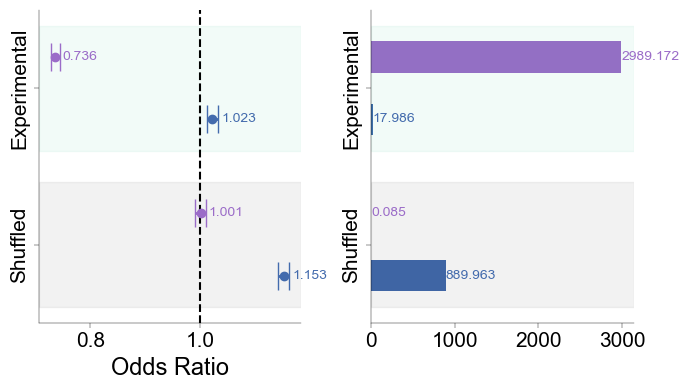

In [17]:
logreg_vals = {
    "Sleep Duration": {k: {"LR":log_reg_outputs[k]['Results']['LR_sleepduration'],
                           "coef": log_reg_outputs[k]['Results']['duration_sleep_coeff'], 
                            "ci_low": log_reg_outputs[k]['Model'].conf_int().loc['duration_sleep'][0],
                           "ci_high": log_reg_outputs[k]['Model'].conf_int().loc['duration_sleep'][1]} 
                       for k in log_reg_outputs.keys()},
    "PKA-SP": {k: {"LR":log_reg_outputs[k]['Results']['LR_pka'],
                            "coef": log_reg_outputs[k]['Results']['pka_sp_coeff'], 
                            "ci_low": log_reg_outputs[k]['Model'].conf_int().loc['pka_sp'][0],
                            "ci_high": log_reg_outputs[k]['Model'].conf_int().loc['pka_sp'][1]} 
               for k in log_reg_outputs.keys()}}

fig,(ax1, ax2) = plt.subplots(figsize=(7, 4), ncols = 2)

predictors = list(logreg_vals.keys())
conditions = list(logreg_vals["Sleep Duration"].keys())
coefs      = [[np.exp(logreg_vals[p][c]["coef"]) for c in conditions] for p in predictors]
ci_lows    = [[np.exp(logreg_vals[p][c]["ci_low"]) for c in conditions] for p in predictors]
ci_highs   = [[np.exp(logreg_vals[p][c]["ci_high"]) for c in conditions] for p in predictors]
colors     = ['#436bad', '#9B6CC8']
y_offset      = [-0.2, 0.2]

for i, (p, coef, low, high) in enumerate(
        zip(predictors, coefs, ci_lows, ci_highs)):
    ax1.errorbar(
        x    = coef[0],
        y    = 1+y_offset[i],
        xerr = [[coef[0] - low[0]], [high[0] - coef[0]]],
        fmt  = "o", color=colors[i], markersize=6,
        capsize=10, lw=2, label=p
    )
    ax1.text(high[0] + 0.005, 1+y_offset[i], f"{coef[0]:.3f}",
         va="center", fontsize=10, color=colors[i])
    ax2.barh(1+y_offset[i], logreg_vals[p]['Experimental']['LR'], color=colors[i], height = 0.2)
    ax2.text(logreg_vals[p]['Experimental']['LR'] + 0.005, 1+y_offset[i], f"{logreg_vals[p]['Experimental']['LR']:.3f}",
         va="center", fontsize=10, color=colors[i])
    ax1.errorbar(
        x    = coef[1],
        y    = 0+y_offset[i],
        xerr = [[coef[1] - low[1]], [high[1] - coef[1]]],
        fmt  = "o", color=colors[i], markersize=6,
        capsize=10, lw=2, label=p
    )
    ax1.text(high[1] + 0.005, 0+y_offset[i], f"{coef[1]:.3f}",
         va="center", fontsize=10, color=colors[i])
    ax2.barh(0+y_offset[i], logreg_vals[p]['Shuffled']['LR'], color=colors[i], height = 0.2)
    ax2.text(logreg_vals[p]['Shuffled']['LR'] + 0.005, 0+y_offset[i], f"{logreg_vals[p]['Shuffled']['LR']:.3f}",
         va="center", fontsize=10, color=colors[i])
ax1.axhspan(0-0.4, 0+0.4, alpha=0.05, color="k")
ax1.axhspan(1-0.4, 1+0.4, alpha=0.05, color='#00b47c')
ax2.axhspan(0-0.4, 0+0.4, alpha=0.05, color="k")
ax2.axhspan(1-0.4, 1+0.4, alpha=0.05, color='#00b47c')


ax1.axvline(1, color='k', linestyle="--", lw=1.5)
ax1.set_ylim(-0.5, 1.5)
ax1.set_yticks([0,1])
ax1.set_yticklabels(['Shuffled', 'Experimental'], rotation = 90, verticalalignment = 'center')
ax2.set_yticks([0,1])
ax2.set_yticklabels(['Shuffled', 'Experimental'], rotation = 90, verticalalignment = 'center')
x_offset = 1-(min(np.concatenate(ci_lows))-0.02)
graph.label_axes(ax1, x = 'Odds Ratio')
graph.match_yaxes([ax1, ax2])
graph.thick_axes(fig, [ax1, ax2], width = 0.3)

fig.tight_layout()
fig.savefig(os.path.join(fig_savedir, 'ModelParams_'+region+'_baseline'+NREM_status+MA_status+'_binsize'+str(waking_binsize)+'.png'))
fig.savefig(os.path.join(fig_savedir, 'ModelParams_'+region+'_baseline'+NREM_status+MA_status+'_binsize'+str(waking_binsize)+'.ps'))

In [18]:
# - - - - - - - - - - - - - - -- - - - - - Threshold Changing - - - - - - - - - - - - - -
wake_prob_range = np.arange(4, 180, 16)
level1 = ['PKA-SP', 'Sleep']
level2 = ['coeff', 'pval', 'CI_Lower', 'CI_Upper', 'LR']

columns = pd.MultiIndex.from_product([level1, level2])
data_df = pd.DataFrame(columns = columns)

for i,w in enumerate(wake_prob_range):
    exp_model_results, exp_fit = PKA.wake_prob_logreg(np.concatenate([grouped_experiments[a]['Grouped Data']['Wake Distance'] 
                                                            for a in grouped_experiments.keys()]), 
                                            np.concatenate([grouped_experiments[a]['Grouped Data']['Sleep Duration'] 
                                                            for a in grouped_experiments.keys()]),
                                            np.concatenate([grouped_experiments[a]['Grouped Data']['FLIM-mAKAR'] 
                                                            for a in grouped_experiments.keys()]),
                                            np.concatenate([[a for i in range(len(grouped_experiments[a]['Grouped Data']['FLIM-mAKAR']))] 
                                                            for a in grouped_experiments.keys()]), 
                                            np.concatenate([grouped_experiments[a]['Grouped Data']['ZT Time'] 
                                                            for a in grouped_experiments.keys()]),
                                                      wake_threshold = w,  standardized = False, gee = False)
    data_df.loc[i, 'PKA-SP'] = [exp_model_results['pka_sp_coeff'], exp_model_results['pka_sp_pval'], 
                                exp_fit.conf_int().loc['pka_sp'].values[0], exp_fit.conf_int().loc['pka_sp'].values[1], 
                               exp_model_results['LR_pka']]
    data_df.loc[i, 'Sleep'] = [exp_model_results['duration_sleep_coeff'], exp_model_results['duration_sleep_pval'], 
                                exp_fit.conf_int().loc['duration_sleep'].values[0], exp_fit.conf_int().loc['duration_sleep'].values[1],
                              exp_model_results['LR_sleepduration']]
data_df['Wake threshold value'] = wake_prob_range

Optimization terminated successfully.
         Current function value: 0.074560
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.073964
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.073956
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.254512
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.252255
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.252241
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.375401
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.372646
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.372629
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.463122
  

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


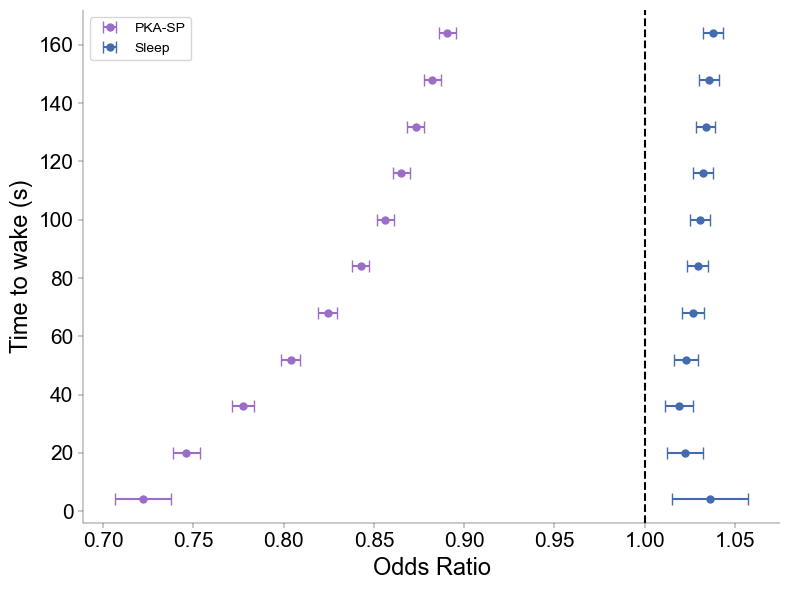

In [19]:
fig, ax = plt.subplots(figsize = [8, 6], ncols = 1)
colors = {'PKA-SP': '#9B6CC8', 'Sleep':'#436BAD'}
for i, k in enumerate(colors.keys()):
    ax.errorbar([np.exp(x) for x in data_df[k]['coeff'].values], data_df['Wake threshold value'], 
                   xerr=[abs(np.exp(x)-np.exp(ci)) for ci, x in zip(data_df[k]['CI_Upper'].values, data_df[k]['coeff'].values)],
               color=colors[k], fmt = "o", markersize = 5, label = k, capsize = 4)

ax.axvline(1, color = 'k', linestyle = '--')
graph.label_axes(ax, x = 'Odds Ratio', y = 'Time to wake (s)')
ax.legend()

fig.tight_layout()
graph.thick_axes(fig, ax, width = 0.3)
fig.savefig(os.path.join(fig_savedir, region+'_baseline'+NREM_status+MA_status+'_binsize_check.ps'))
